# Bayesian ridge regression for AOR Prediction - Jupyter Notebook

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

In [2]:
# Import the function from the external file
from data.extract_data import extract_sections_by_elements, combine_elements_data

%load_ext autoreload
%autoreload 2

In [3]:
# Call the function to extract sections by element
elements_data = extract_sections_by_elements()

In [4]:
# Call the function to combine data
combined_data = combine_elements_data(elements_data)

In [5]:
X=combined_data[['A', 'B', 'C', 'D', 'E', 'F', 'G']]
y=combined_data['AOR']

In [7]:
# Split the dataset into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
# Train the Bayesian Ridge Regression model
bayesian_ridge_model = BayesianRidge()
bayesian_ridge_model.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = bayesian_ridge_model.predict(X_test_scaled)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 6.78290299568932
R-squared: 0.7592185155772576


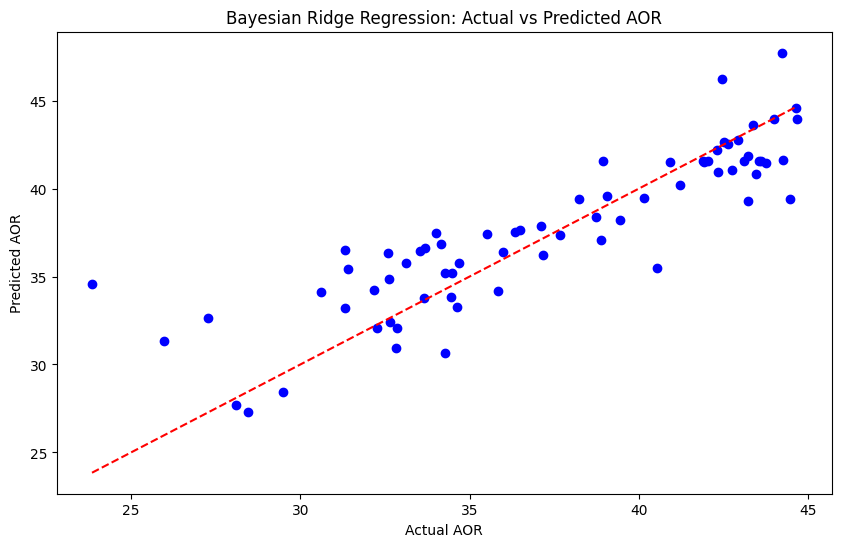

Model Coefficients: [ 0.5709864   3.0134031  -2.78770927  1.24307986  1.43906571 -0.37385279
  1.23162636]
Model Intercept: 36.52694542253521
Alpha (Precision of Weights): 0.06478712935316557
Lambda (Precision of Noise): 0.3047744252335812


In [11]:
# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('Actual AOR')
plt.ylabel('Predicted AOR')
plt.title('Bayesian Ridge Regression: Actual vs Predicted AOR')
plt.show()

# Model coefficients
print("Model Coefficients:", bayesian_ridge_model.coef_)
print("Model Intercept:", bayesian_ridge_model.intercept_)

# Uncertainty estimates (alpha and lambda are the precision of the weights and noise respectively)
print("Alpha (Precision of Weights):", bayesian_ridge_model.alpha_)
print("Lambda (Precision of Noise):", bayesian_ridge_model.lambda_)